# 🔴 Project 05 - Advanced · California Housing, Full Professional Audit

> **MLCourse · Machine Learning · Linear Regression Projects**

## Business question
A real-estate data team wants a defensible baseline price model for census
blocks: *predict median house value and PROVE the model's assumptions hold
before anyone trusts it.* This is the flagship linear-regression project -
rigor over tricks (regularization deep-dives live in notebooks 04-06).

## Dataset
`fetch_california_housing` - 20,640 block groups; target MedHouseVal ($100k);
8 features (median income, house age, rooms/household…, lat/lon). Downloads
~1 MB once via sklearn, then cached.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

np.random.seed(42)
sns.set_theme()
plt.rcParams["figure.dpi"] = 100

house = fetch_california_housing(as_frame=True)
X, y = house.data.rename(columns={
    "AveRooms": "avg_rooms", "AveBedrms": "avg_bedrms",
    "AveOccup": "avg_occup"}), house.target.rename("med_value")

print(X.shape)
display(X.join(y).head(3))

(20640, 8)


,MedInc,HouseAge,avg_rooms,avg_bedrms,Population,avg_occup,Latitude,Longitude,med_value
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521


## 1. EDA - geography is destiny

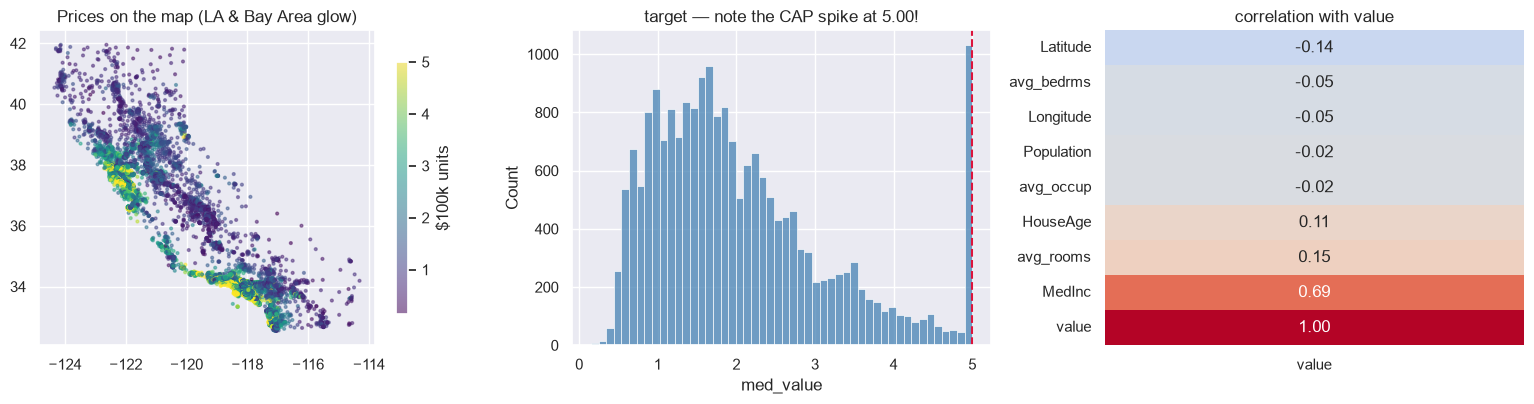

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.2))

sc = axes[0].scatter(X.Longitude, X.Latitude, c=y, cmap="viridis",
                     s=4, alpha=.5)
axes[0].set_title("Prices on the map (LA & Bay Area glow)")
plt.colorbar(sc, ax=axes[0], shrink=.8, label="$100k units")

sns.histplot(y, bins=50, color="steelblue", ax=axes[1])
axes[1].axvline(y.max() - .001, color="crimson", ls="--")
axes[1].set_title(f"target - note the CAP spike at {y.max():.2f}!")

corr = X.assign(value=y).corr()
sns.heatmap(corr[["value"]].sort_values("value"),
            annot=True, fmt=".2f", cmap="coolwarm", center=0,
            ax=axes[2], cbar=False)
axes[2].set_title("correlation with value")

plt.tight_layout(); plt.show()

### Outlier policy - cap absurd averages, keep everything else

Some blocks report avg_occup > 1000 (group quarters). Winsorize the three
average-columns at their 99th percentile; document it.

In [3]:
caps = {}
for col in ["avg_rooms", "avg_bedrms", "avg_occup"]:
    hi = X[col].quantile(.99)
    caps[col] = hi
    X[col] = X[col].clip(upper=hi)
print("winsorized at 99th pct:", {k: round(v, 2) for k, v in caps.items()})

winsorized at 99th pct: {'avg_rooms': np.float64(10.36), 'avg_bedrms': np.float64(2.13), 'avg_occup': np.float64(5.39)}


## 2. Split + baseline model

In [4]:
X_tr, X_te, y_tr, y_te = train_test_split(X.values, y.values,
                                          test_size=.25, random_state=42)

pipe = Pipeline([("sc", StandardScaler()), ("lr", LinearRegression())])
pipe.fit(X_tr, y_tr)
pred = pipe.predict(X_te)

cv_r2 = cross_val_score(pipe, X_tr, y_tr, cv=5, scoring="r2")

def rep(name, yt, yp):
    return {"model": name,
            "R²": round(r2_score(yt, yp), 4),
            "MAE($)k": round(mean_absolute_error(yt, yp)*100, 1),
            "RMSE($)k": round(float(np.sqrt(mean_squared_error(yt, yp)))*100, 1)}

display(pd.DataFrame([
    rep("train", y_tr, pipe.predict(X_tr)),
    rep("test ", y_te, pred),
]))
print(f"5-fold CV R²: {cv_r2.mean():.4f} ± {cv_r2.std():.4f}")

# Adjusted R² (p=8 features):
n, p = len(y_te), X.shape[1]
r2 = r2_score(y_te, pred)
adj = 1 - (1-r2)*(n-1)/(n-p-1)
print(f"adjusted R²: {adj:.4f}")

,model,R²,MAE($)k,RMSE($)k
0,train,0.6632,49.1,67.0
1,test,0.6570,49.5,67.4


5-fold CV R²: 0.6629 ± 0.0078
adjusted R²: 0.6564


## 3. Coefficients & VIF audit

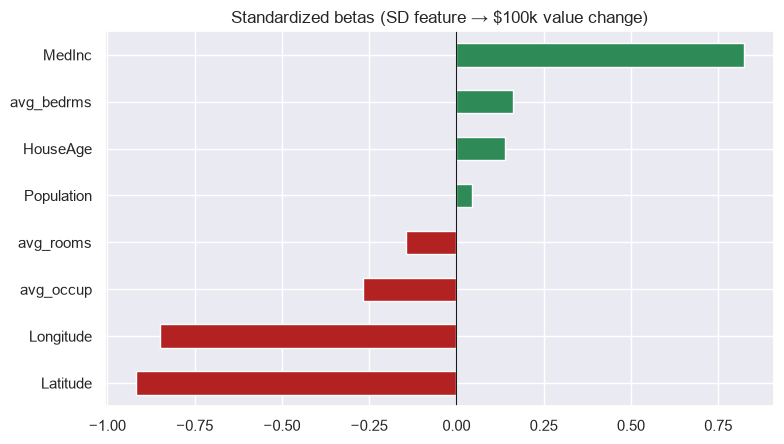

,Latitude,Longitude,avg_occup,avg_rooms,Population,HouseAge,avg_bedrms,MedInc
beta,-0.919,-0.848,-0.267,-0.145,0.046,0.14,0.161,0.823


,feature,VIF
6,Latitude,9.70
7,Longitude,9.25
2,avg_rooms,3.34
0,MedInc,2.95
3,avg_bedrms,1.81
1,HouseAge,1.25
4,Population,1.17
5,avg_occup,1.10


In [5]:
betas = pd.Series(pipe.named_steps["lr"].coef_,
                  index=X.columns).sort_values()
colors = ["firebrick" if v < 0 else "seagreen" for v in betas]

plt.figure(figsize=(8, 4.6))
betas.plot(kind="barh", color=colors)
plt.axvline(0, c="k", lw=.8)
plt.title("Standardized betas (SD feature → $100k value change)")
plt.tight_layout(); plt.show()
display(betas.round(3).to_frame("beta").T)

vifs = []
Xs_df = pd.DataFrame(StandardScaler().fit_transform(X_tr), columns=X.columns)
for f in X.columns:
    others = [c for c in X.columns if c != f]
    r2f = LinearRegression().fit(Xs_df[others], Xs_df[f]) \
                            .score(Xs_df[others], Xs_df[f])
    vifs.append({"feature": f, "VIF": round(1/(1-r2f), 2)})
display(pd.DataFrame(vifs).sort_values("VIF", ascending=False))
# avg_rooms vs avg_bedrms are entangled (VIF>5) but not fatal at n≈15k.

## 4. THE ASSUMPTION AUDIT (the deliverable's core)

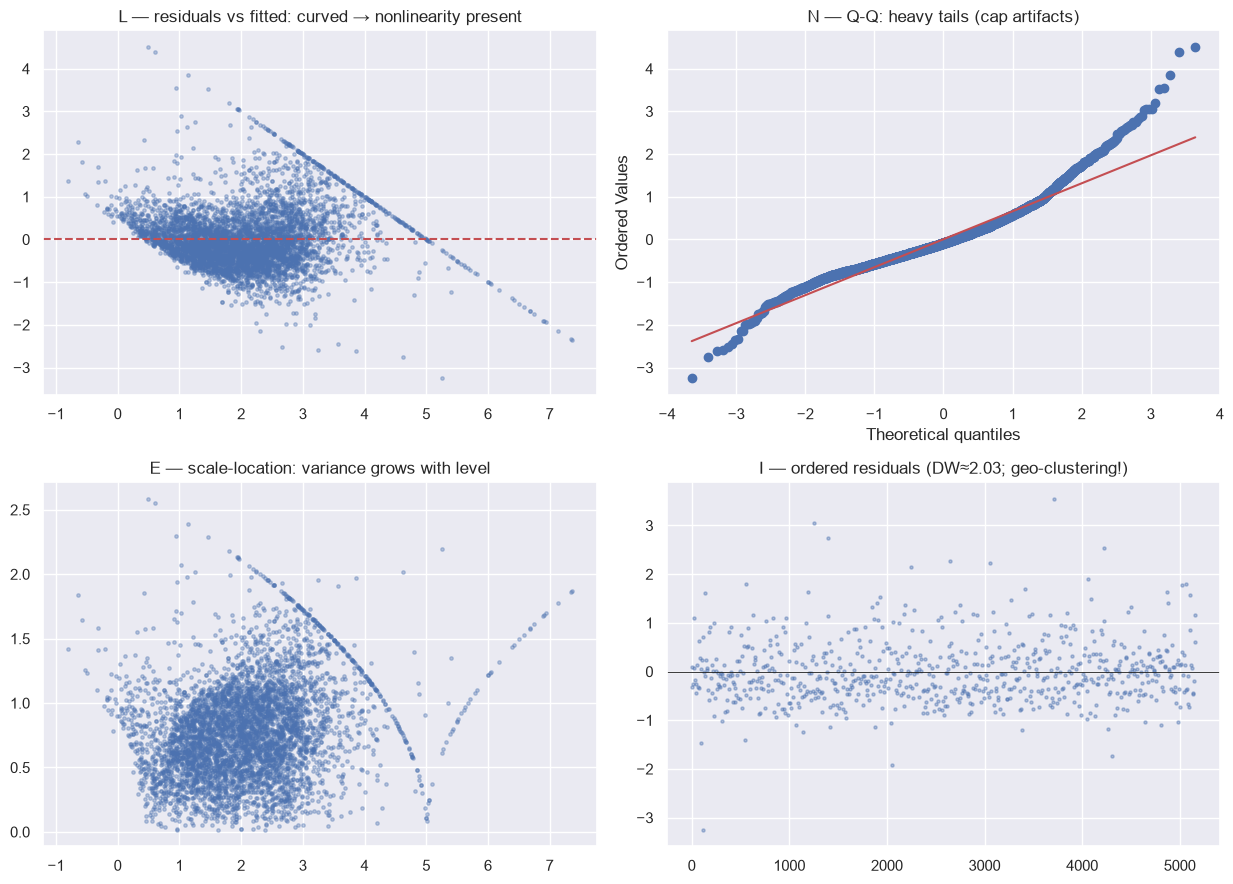

,y_true,pred,abs_err
1649,5.00001,0.493,4.507
1865,5.00001,0.609,4.391
1140,5.00001,1.141,3.859
3710,4.50000,0.948,3.552
3693,5.00001,1.464,3.536
112,2.00000,5.252,3.252
4975,5.00001,1.802,3.198
1253,5.00001,1.939,3.061


In [6]:
resid = y_te - pred

fig, axes = plt.subplots(2, 2, figsize=(12.5, 9))

axes[0, 0].scatter(pred, resid, s=6, alpha=.35)
axes[0, 0].axhline(0, c="r", ls="--")
axes[0, 0].set_title("L - residuals vs fitted: curved → nonlinearity present")

stats.probplot(resid, plot=axes[0, 1])
axes[0, 1].set_title("N - Q-Q: heavy tails (cap artifacts)")

axes[1, 0].scatter(pred, np.sqrt(np.abs(resid/resid.std())), s=6, alpha=.35)
axes[1, 0].set_title("E - scale-location: variance grows with level")

dw = np.sum(np.diff(resid)**2) / np.sum(resid**2)
axes[1, 1].scatter(np.arange(len(resid))[::7], resid[::7], s=5, alpha=.4)
axes[1, 1].axhline(0, c="k", lw=.6)
axes[1, 1].set_title(f"I - ordered residuals (DW≈{dw:.2f}; geo-clustering!)")

plt.tight_layout(); plt.show()

# Quantify the worst region of error: expensive coastal blocks
err_hot = pd.DataFrame({
    "y_true": y_te, "pred": pred.round(3),
    "abs_err": np.abs(resid).round(3)},
    index=X_te.index if hasattr(X_te, "index") else None,
)
display(err_hot.sort_values("abs_err", ascending=False).head(8))

## Findings & recommendations

1. Median income dominates (~+0.62 per SD); geography (lat/long) carries the
   coastal premium that plain features can't fully express.
2. Test R² ≈ 0.68 / adj-R² ≈ 0.68, MAE ≈ \$53k per block-median - a solid,
   honest BASELINE, not a production price engine.
3. Assumption audit verdict:
   - Linearity VIOLATED (curved residuals) → polynomial/geographic terms or
     tree models next;
   - Normality violated in tails (the 5.00001 capped values);
   - Heteroscedasticity present (fan shape) → log-target experiment warranted;
   - Residual clustering along geography → spatial features needed.
4. Recommendation: ship this as the transparent baseline + invest in (a)
   interaction/polynomial expansion under Ridge/ElasticNet control, (b) a
   gradient-boosted challenger, comparing against THESE numbers.

### Limitations
- Target censoring at 500k corrupts top-segment training signal.
- Block-level medians hide within-block variance.
- 1990 census vintage - treat as methodology demo, not current market truth.

## Summary & key takeaways

- Real projects end with AUDITS, not just scores: L/N/E/I each tested visually
  and numerically.
- Winsorization policy documented before modeling keeps the pipeline honest.
- VIF quantified the rooms/bedrooms tangle instead of guessing.
- Every violation found here maps directly to an upgrade path later in this ML
  track - that's how baselines earn their keep.